# Predicao de `winner_side` do proximo round (t+1)

### Objetivo

Prever, no fim do round `t`, quem vence o round `t+1` (`CT` ou `T`) usando dados da camada Gold no MinIO.


### Origem dos dados

Neste notebook usamos `round_context.csv` da Gold (MinIO).

In [1]:
# Instalacao opcional (se necessario)
# !pip install pandas numpy scikit-learn mlflow minio python-dotenv seaborn matplotlib -q


## 1) Ler o dataset da Gold (MinIO)

In [2]:
from __future__ import annotations

from io import BytesIO
from pathlib import Path
import os
import sys

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(style="whitegrid", context="talk")
from dotenv import load_dotenv
from minio import Minio

root = Path.cwd()
if (root / "src").exists():
    sys.path.append(str(root / "src"))
elif (root.parent / "src").exists():
    sys.path.append(str(root.parent / "src"))

from rag_intelligence.gold import build_gold_events_key

if (root / ".env").exists():
    load_dotenv(root / ".env")
elif (root.parent / ".env").exists():
    load_dotenv(root.parent / ".env")

pd.set_option("display.max_columns", 120)


In [3]:
def parse_bool(value: str) -> bool:
    return str(value).strip().lower() in {"1", "true", "yes", "on"}

LOCAL_ROUND_CONTEXT_CSV = os.getenv("LOCAL_ROUND_CONTEXT_CSV", "").strip()

if LOCAL_ROUND_CONTEXT_CSV:
    round_context_df = pd.read_csv(LOCAL_ROUND_CONTEXT_CSV, low_memory=False)
    print(f"Loaded local CSV: {LOCAL_ROUND_CONTEXT_CSV}")
else:
    minio_client = Minio(
        endpoint=os.getenv("MINIO_ENDPOINT", "localhost:9000"),
        access_key=os.getenv("MINIO_ACCESS_KEY", "minioadmin"),
        secret_key=os.getenv("MINIO_SECRET_KEY", "minioadmin"),
        secure=parse_bool(os.getenv("MINIO_SECURE", "false")),
    )

    dataset_prefix = (
        os.getenv("GOLD_DATASET_PREFIX")
        or os.getenv("SILVER_DATASET_PREFIX")
        or os.getenv("BRONZE_DATASET_PREFIX")
    )
    run_id = os.getenv("GOLD_SOURCE_RUN_ID") or os.getenv("GOLD_RUN_ID")
    gold_bucket = os.getenv("GOLD_BUCKET", "gold")

    # Em modo ML-first, build_gold_events_key aponta para curated/round_context.csv
    round_context_key = build_gold_events_key(dataset_prefix, run_id)
    print(f"Bucket: {gold_bucket}")
    print(f"Object key: {round_context_key}")

    response = minio_client.get_object(gold_bucket, round_context_key)
    try:
        round_context_df = pd.read_csv(BytesIO(response.read()), low_memory=False)
    finally:
        response.close()
        response.release_conn()

print(round_context_df.shape)
round_context_df.head()


Bucket: gold
Object key: csgo-matchmaking-damage/20260306T025119Z/curated/round_context.csv


(377628, 10)


,file,round_number,map,round_type,winner_side_current,ct_eq_val,t_eq_val,eq_diff,half,overtime_flag
0,esea_match_13770997.dem,1,de_overpass,PISTOL_ROUND,T,4300,4250,50,H1,0
1,esea_match_13770997.dem,2,de_overpass,ECO,T,6300,19400,-13100,H1,0
2,esea_match_13770997.dem,3,de_overpass,SEMI_ECO,T,7650,19250,-11600,H1,0
3,esea_match_13770997.dem,4,de_overpass,NORMAL,T,24900,23400,1500,H1,0
4,esea_match_13770997.dem,5,de_overpass,ECO,CT,5400,20550,-15150,H1,0


## 2) Entender os dados

In [4]:
round_context_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 377628 entries, 0 to 377627
Data columns (total 10 columns):
 #   Column               Non-Null Count   Dtype 
---  ------               --------------   ----- 
 0   file                 377628 non-null  object
 1   round_number         377628 non-null  int64 
 2   map                  377628 non-null  object
 3   round_type           377628 non-null  object
 4   winner_side_current  377628 non-null  object
 5   ct_eq_val            377628 non-null  int64 
 6   t_eq_val             377628 non-null  int64 
 7   eq_diff              377628 non-null  int64 
 8   half                 377628 non-null  object
 9   overtime_flag        377628 non-null  int64 
dtypes: int64(5), object(5)
memory usage: 28.8+ MB


In [5]:
round_context_df.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
file,377628,14921,esea_match_13785283.dem,62,NaN,NaN,NaN,NaN,NaN,NaN,NaN
round_number,377628.0,NaN,NaN,NaN,13.705271,8.048993,1.0,7.0,13.0,20.0,63.0
map,377628,8,de_mirage,132861,NaN,NaN,NaN,NaN,NaN,NaN,NaN
round_type,377628,5,NORMAL,155582,NaN,NaN,NaN,NaN,NaN,NaN,NaN
winner_side_current,377628,2,T,193614,NaN,NaN,NaN,NaN,NaN,NaN,NaN
ct_eq_val,377628.0,NaN,NaN,NaN,18995.289412,10500.189833,200.0,7700.0,21850.0,28150.0,42050.0
t_eq_val,377628.0,NaN,NaN,NaN,18365.792791,8760.263481,400.0,11300.0,21250.0,25500.0,38150.0
eq_diff,377628.0,NaN,NaN,NaN,629.496621,13780.404453,-32800.0,-10100.0,550.0,10650.0,36450.0
half,377628,2,H1,226257,NaN,NaN,NaN,NaN,NaN,NaN,NaN
overtime_flag,377628.0,NaN,NaN,NaN,0.012367,0.110516,0.0,0.0,0.0,0.0,1.0


In [6]:
missing_pct = (round_context_df.isna().mean() * 100).sort_values(ascending=False)
missing_pct


file                   0.0
round_number           0.0
map                    0.0
round_type             0.0
winner_side_current    0.0
ct_eq_val              0.0
t_eq_val               0.0
eq_diff                0.0
half                   0.0
overtime_flag          0.0
dtype: float64

In [7]:
round_context_df["winner_side_current"].value_counts(dropna=False, normalize=True)


winner_side_current
T     0.512711
CT    0.487289
Name: proportion, dtype: float64

### Graficos de justificativa (EDA)

Assim como no notebook de referencia, usamos graficos para justificar comportamento dos dados antes do treino.


C:\Users\Pedro\AppData\Local\Temp\ipykernel_31756\1259580176.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


C:\Users\Pedro\AppData\Local\Temp\ipykernel_31756\1259580176.py:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


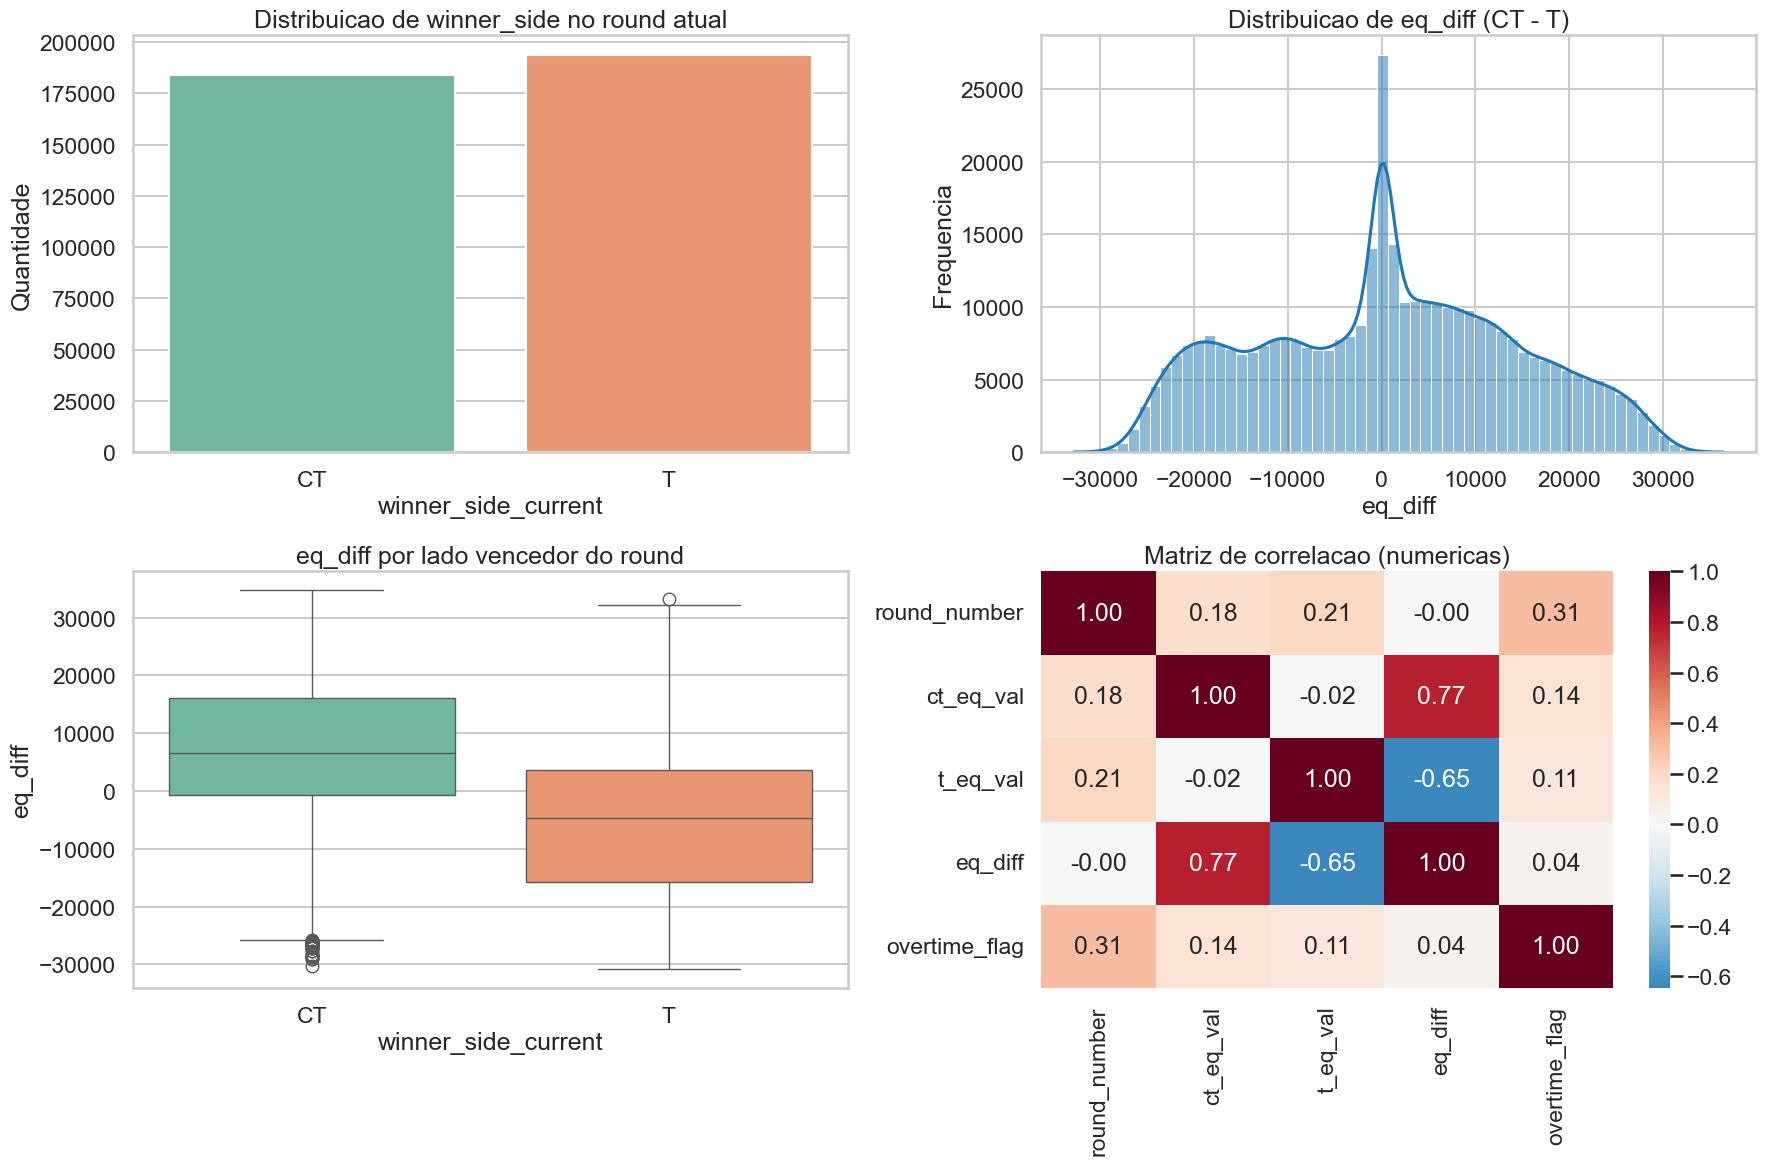

In [8]:
fig, axes = plt.subplots(2, 2, figsize=(18, 12))

side_order = ["CT", "T"]

# 1) Balanceamento da classe atual
sns.countplot(
    data=round_context_df,
    x="winner_side_current",
    order=side_order,
    ax=axes[0, 0],
    palette="Set2",
)
axes[0, 0].set_title("Distribuicao de winner_side no round atual")
axes[0, 0].set_xlabel("winner_side_current")
axes[0, 0].set_ylabel("Quantidade")

# 2) Distribuicao da diferenca de economia
sns.histplot(round_context_df["eq_diff"], bins=60, kde=True, ax=axes[0, 1], color="#1f77b4")
axes[0, 1].set_title("Distribuicao de eq_diff (CT - T)")
axes[0, 1].set_xlabel("eq_diff")
axes[0, 1].set_ylabel("Frequencia")

# 3) Economia relativa por lado vencedor
sample_for_box = round_context_df.sample(min(50000, len(round_context_df)), random_state=42)
sns.boxplot(
    data=sample_for_box,
    x="winner_side_current",
    y="eq_diff",
    order=side_order,
    ax=axes[1, 0],
    palette="Set2",
)
axes[1, 0].set_title("eq_diff por lado vencedor do round")
axes[1, 0].set_xlabel("winner_side_current")
axes[1, 0].set_ylabel("eq_diff")

# 4) Correlacao entre variaveis numericas principais
corr_cols = ["round_number", "ct_eq_val", "t_eq_val", "eq_diff", "overtime_flag"]
corr = round_context_df[corr_cols].corr(numeric_only=True)
sns.heatmap(corr, annot=True, fmt=".2f", cmap="RdBu_r", center=0, ax=axes[1, 1])
axes[1, 1].set_title("Matriz de correlacao (numericas)")

plt.tight_layout()
plt.show()


## 3) Funcoes do pre-processamento (explicadas no notebook)

Para facilitar a apresentacao para o professor, abaixo estao as funcoes principais usadas no pipeline.

- `build_round_level_frame`: padroniza o dataset de round, limpa e organiza.
- `build_supervised_frame`: cria o alvo de `t+1` e as features temporais (lags/rolling).
- `run_consistency_checks`: valida se nao houve vazamento temporal.


In [9]:
from typing import Any
import numpy as np

_WINNER_CT_VALUES = {"CT", "COUNTERTERRORIST", "COUNTER_TERRORIST", "COUNTER-TERRORIST"}
_WINNER_T_VALUES = {"T", "TERRORIST"}


def normalize_winner_side(value: Any) -> str | None:
    # Normaliza labels de vencedor para CT/T.
    if value is None:
        return None
    text = str(value).strip().upper()
    if text in _WINNER_CT_VALUES:
        return "CT"
    if text in _WINNER_T_VALUES:
        return "T"
    return None


def _to_numeric(series: pd.Series) -> pd.Series:
    return pd.to_numeric(series, errors="coerce")


def build_round_level_frame(round_context_df: pd.DataFrame) -> pd.DataFrame:
    # Prepara a base por round com schema padrao e ordenacao temporal.
    required = {
        "file",
        "round_number",
        "map",
        "round_type",
        "winner_side_current",
        "ct_eq_val",
        "t_eq_val",
        "eq_diff",
        "half",
        "overtime_flag",
    }
    missing = sorted(required.difference(round_context_df.columns))
    if missing:
        raise ValueError(f"round_context_df sem colunas obrigatorias: {', '.join(missing)}")

    df = round_context_df.copy()

    df["round_number"] = _to_numeric(df["round_number"]).astype("Int64")
    df = df.dropna(subset=["file", "round_number", "map", "winner_side_current"]).copy()
    df["round_number"] = df["round_number"].astype(int)

    df["ct_eq_val"] = _to_numeric(df["ct_eq_val"])
    df["t_eq_val"] = _to_numeric(df["t_eq_val"])
    df["eq_diff"] = _to_numeric(df["eq_diff"]).fillna(df["ct_eq_val"] - df["t_eq_val"])
    df["overtime_flag"] = _to_numeric(df["overtime_flag"]).fillna(0).astype(int)

    df["winner_side_norm"] = df["winner_side_current"].apply(normalize_winner_side)
    df = df.dropna(subset=["winner_side_norm"]).copy()
    df["winner_side_code"] = (df["winner_side_norm"] == "CT").astype(int)

    df["round_type"] = df["round_type"].fillna("unknown").astype(str)
    df["half"] = df["half"].fillna("H1").astype(str)
    df["map"] = df["map"].fillna("unknown").astype(str)

    # Garante uma linha por (partida, round).
    df = (
        df.sort_values(["file", "round_number"])
        .drop_duplicates(subset=["file", "round_number"], keep="last")
        .reset_index(drop=True)
    )
    return df


def build_supervised_frame(
    round_df: pd.DataFrame,
    *,
    lag_steps: tuple[int, ...] = (1, 2, 3),
    rolling_window: int = 3,
) -> pd.DataFrame:
    # Cria o alvo do proximo round e features de historico recente.
    required = {
        "file",
        "round_number",
        "winner_side_norm",
        "winner_side_code",
        "ct_eq_val",
        "t_eq_val",
        "eq_diff",
        "map",
        "round_type",
        "half",
        "overtime_flag",
    }
    missing = sorted(required.difference(round_df.columns))
    if missing:
        raise ValueError(f"round_df sem colunas obrigatorias: {', '.join(missing)}")

    df = round_df.sort_values(["file", "round_number"]).copy()
    grouped = df.groupby("file", sort=False)

    # Alvo supervisionado: vencedor no round seguinte (t+1).
    df["target_winner_side_next"] = grouped["winner_side_norm"].shift(-1)
    df["target_winner_side_next_code"] = grouped["winner_side_code"].shift(-1)

    # Lags: somente passado da propria partida.
    for column in ("eq_diff", "winner_side_code", "ct_eq_val", "t_eq_val"):
        for lag in lag_steps:
            df[f"{column}_lag{lag}"] = grouped[column].shift(lag)

    # Rolling mean olhando apenas para rounds anteriores.
    roll_name = f"eq_diff_rollmean{rolling_window}"
    rolled = grouped["eq_diff"].shift(1).rolling(window=rolling_window, min_periods=1).mean()
    df[roll_name] = rolled.reset_index(level=0, drop=True)

    df = df.dropna(subset=["target_winner_side_next", "target_winner_side_next_code"]).copy()
    df["target_winner_side_next_code"] = df["target_winner_side_next_code"].astype(int)
    return df


def run_consistency_checks(supervised_df: pd.DataFrame) -> dict[str, int | bool]:
    # Checa deduplicacao e causalidade temporal de target/lags.
    sorted_df = supervised_df.sort_values(["file", "round_number"]).copy()

    duplicate_round_keys = int(sorted_df.duplicated(subset=["file", "round_number"]).sum())

    expected_target = sorted_df.groupby("file", sort=False)["winner_side_norm"].shift(-1)
    expected_target = expected_target.dropna()
    actual_target = sorted_df.loc[expected_target.index, "target_winner_side_next"]
    shift_matches = bool((actual_target == expected_target).all())

    expected_lag1 = sorted_df.groupby("file", sort=False)["winner_side_code"].shift(1)
    lag_mask = expected_lag1.notna()
    lag_matches = bool((sorted_df.loc[lag_mask, "winner_side_code_lag1"] == expected_lag1.loc[lag_mask]).all())

    return {
        "duplicate_round_keys": duplicate_round_keys,
        "target_shift_is_valid": shift_matches,
        "lag1_is_past_only": lag_matches,
    }


In [10]:
round_df = build_round_level_frame(round_context_df)
print("round_df shape:", round_df.shape)
round_df.head()


round_df shape: (377628, 12)


,file,round_number,map,round_type,winner_side_current,ct_eq_val,t_eq_val,eq_diff,half,overtime_flag,winner_side_norm,winner_side_code
0,esea_match_13770997.dem,1,de_overpass,PISTOL_ROUND,T,4300,4250,50,H1,0,T,0
1,esea_match_13770997.dem,2,de_overpass,ECO,T,6300,19400,-13100,H1,0,T,0
2,esea_match_13770997.dem,3,de_overpass,SEMI_ECO,T,7650,19250,-11600,H1,0,T,0
3,esea_match_13770997.dem,4,de_overpass,NORMAL,T,24900,23400,1500,H1,0,T,0
4,esea_match_13770997.dem,5,de_overpass,ECO,CT,5400,20550,-15150,H1,0,CT,1


In [11]:
supervised_df = build_supervised_frame(round_df, lag_steps=(1, 2, 3), rolling_window=3)
checks = run_consistency_checks(supervised_df)

print("supervised_df shape:", supervised_df.shape)
print("checks:", checks)

assert checks["duplicate_round_keys"] == 0
assert checks["target_shift_is_valid"] is True
assert checks["lag1_is_past_only"] is True

supervised_df.head()


supervised_df shape: (362707, 27)
checks: {'duplicate_round_keys': 0, 'target_shift_is_valid': True, 'lag1_is_past_only': True}


,file,round_number,map,round_type,winner_side_current,ct_eq_val,t_eq_val,eq_diff,half,overtime_flag,winner_side_norm,winner_side_code,target_winner_side_next,target_winner_side_next_code,eq_diff_lag1,eq_diff_lag2,eq_diff_lag3,winner_side_code_lag1,winner_side_code_lag2,winner_side_code_lag3,ct_eq_val_lag1,ct_eq_val_lag2,ct_eq_val_lag3,t_eq_val_lag1,t_eq_val_lag2,t_eq_val_lag3,eq_diff_rollmean3
0,esea_match_13770997.dem,1,de_overpass,PISTOL_ROUND,T,4300,4250,50,H1,0,T,0,T,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,esea_match_13770997.dem,2,de_overpass,ECO,T,6300,19400,-13100,H1,0,T,0,T,0,50.0,NaN,NaN,0.0,NaN,NaN,4300.0,NaN,NaN,4250.0,NaN,NaN,50.000000
2,esea_match_13770997.dem,3,de_overpass,SEMI_ECO,T,7650,19250,-11600,H1,0,T,0,T,0,-13100.0,50.0,NaN,0.0,0.0,NaN,6300.0,4300.0,NaN,19400.0,4250.0,NaN,-6525.000000
3,esea_match_13770997.dem,4,de_overpass,NORMAL,T,24900,23400,1500,H1,0,T,0,CT,1,-11600.0,-13100.0,50.0,0.0,0.0,0.0,7650.0,6300.0,4300.0,19250.0,19400.0,4250.0,-8216.666667
4,esea_match_13770997.dem,5,de_overpass,ECO,CT,5400,20550,-15150,H1,0,CT,1,T,0,1500.0,-11600.0,-13100.0,0.0,0.0,0.0,24900.0,7650.0,6300.0,23400.0,19250.0,19400.0,-7733.333333


### Graficos do dataset supervisionado

Aqui mostramos o alvo `t+1` e o comportamento de variaveis temporais criadas.


C:\Users\Pedro\AppData\Local\Temp\ipykernel_31756\2395332971.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


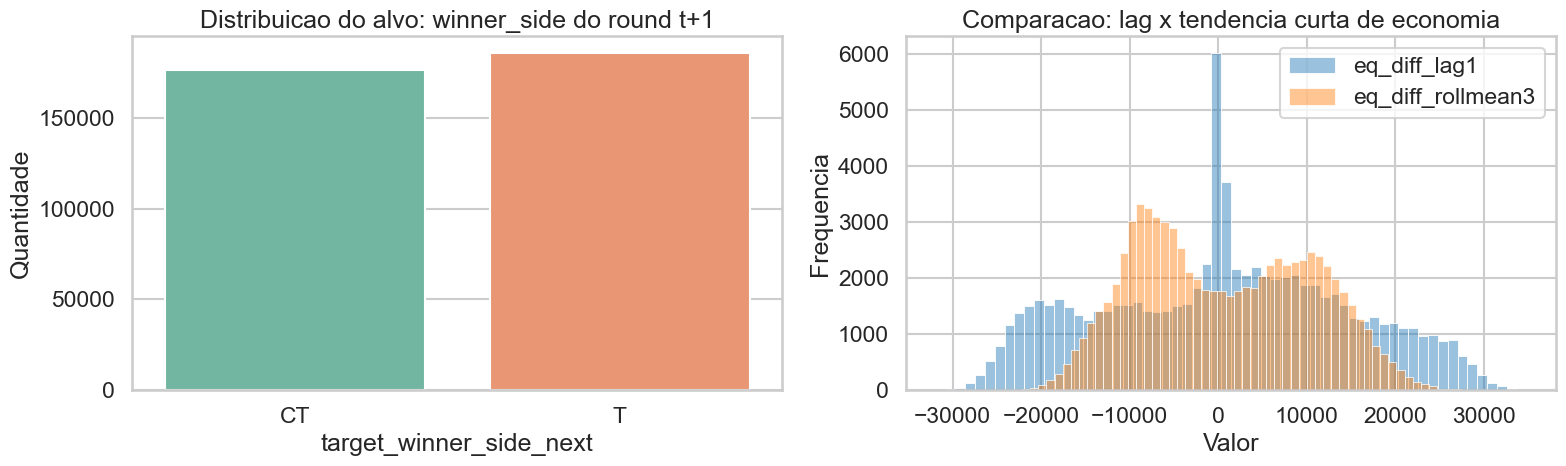

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Distribuicao do alvo do proximo round
sns.countplot(
    data=supervised_df,
    x="target_winner_side_next",
    order=["CT", "T"],
    ax=axes[0],
    palette="Set2",
)
axes[0].set_title("Distribuicao do alvo: winner_side do round t+1")
axes[0].set_xlabel("target_winner_side_next")
axes[0].set_ylabel("Quantidade")

# Distribuicao de features temporais de economia
temp_sample = supervised_df[["eq_diff_lag1", "eq_diff_rollmean3"]].dropna()
temp_sample = temp_sample.sample(min(80000, len(temp_sample)), random_state=42)

sns.histplot(temp_sample["eq_diff_lag1"], bins=60, alpha=0.45, color="#1f77b4", label="eq_diff_lag1", ax=axes[1])
sns.histplot(temp_sample["eq_diff_rollmean3"], bins=60, alpha=0.45, color="#ff7f0e", label="eq_diff_rollmean3", ax=axes[1])
axes[1].set_title("Comparacao: lag x tendencia curta de economia")
axes[1].set_xlabel("Valor")
axes[1].set_ylabel("Frequencia")
axes[1].legend()

plt.tight_layout()
plt.show()


## 4) Features usadas (explicacao simples)

In [13]:
feature_explanation = pd.DataFrame([
    {"feature": "ct_eq_val", "tipo": "numerica", "significado": "Economia atual do lado CT no round t"},
    {"feature": "t_eq_val", "tipo": "numerica", "significado": "Economia atual do lado T no round t"},
    {"feature": "eq_diff", "tipo": "numerica", "significado": "Diferenca de economia (CT - T) no round t"},
    {"feature": "winner_side_norm", "tipo": "categorica", "significado": "Quem venceu o round atual (t)"},
    {"feature": "round_type", "tipo": "categorica", "significado": "Tipo do round (pistol, eco, gunround...)"},
    {"feature": "half", "tipo": "categorica", "significado": "Metade da partida (H1/H2)"},
    {"feature": "overtime_flag", "tipo": "numerica", "significado": "Indica se esta em overtime (1) ou nao (0)"},
    {"feature": "eq_diff_lag1/2/3", "tipo": "temporal", "significado": "Historico recente da diferenca de economia"},
    {"feature": "winner_side_code_lag1/2/3", "tipo": "temporal", "significado": "Historico recente de vencedores"},
    {"feature": "eq_diff_rollmean3", "tipo": "temporal", "significado": "Tendencia curta da diferenca de economia"},
])

feature_explanation


,feature,tipo,significado
0,ct_eq_val,numerica,Economia atual do lado CT no round t
1,t_eq_val,numerica,Economia atual do lado T no round t
2,eq_diff,numerica,Diferenca de economia (CT - T) no round t
3,winner_side_norm,categorica,Quem venceu o round atual (t)
4,round_type,categorica,"Tipo do round (pistol, eco, gunround...)"
5,half,categorica,Metade da partida (H1/H2)
6,overtime_flag,numerica,Indica se esta em overtime (1) ou nao (0)
7,eq_diff_lag1/2/3,temporal,Historico recente da diferenca de economia
8,winner_side_code_lag1/2/3,temporal,Historico recente de vencedores
9,eq_diff_rollmean3,temporal,Tendencia curta da diferenca de economia


In [14]:
supervised_df["target_winner_side_next"].value_counts(normalize=True)


target_winner_side_next
T     0.512471
CT    0.487529
Name: proportion, dtype: float64

## 5) Treino dos modelos

Split por partida (`file`) para evitar vazamento entre treino e teste.


In [15]:
from rag_intelligence.round_winner import train_next_round_winner

training_output = train_next_round_winner(
    supervised_df,
    test_size=0.2,
    random_state=42,
    min_segment_rows=200,
)

print("Train rows:", training_output.train_rows)
print("Test rows:", training_output.test_rows)
print("Train files:", len(training_output.train_files))
print("Test files:", len(training_output.test_files))
print("File overlap:", len(training_output.train_files.intersection(training_output.test_files)))


Train rows: 290108
Test rows: 72599
Train files: 11936
Test files: 2985
File overlap: 0


In [16]:
# Modelos avaliados:
# 1) baseline_repeat_current_winner
# 2) logistic_regression
# 3) hist_gradient_boosting
training_output.metrics.sort_values("roc_auc", ascending=False).reset_index(drop=True)


,model,roc_auc,f1,balanced_accuracy,log_loss,brier
0,hist_gradient_boosting,0.724385,0.666012,0.663036,0.611851,0.211850
1,logistic_regression,0.686243,0.650729,0.657366,0.637188,0.222702
2,baseline_repeat_current_winner,0.657641,0.651010,0.657641,4.728167,0.342235


### Graficos de desempenho dos modelos

Estes graficos ajudam a justificar qual modelo performa melhor nas metricas principais.


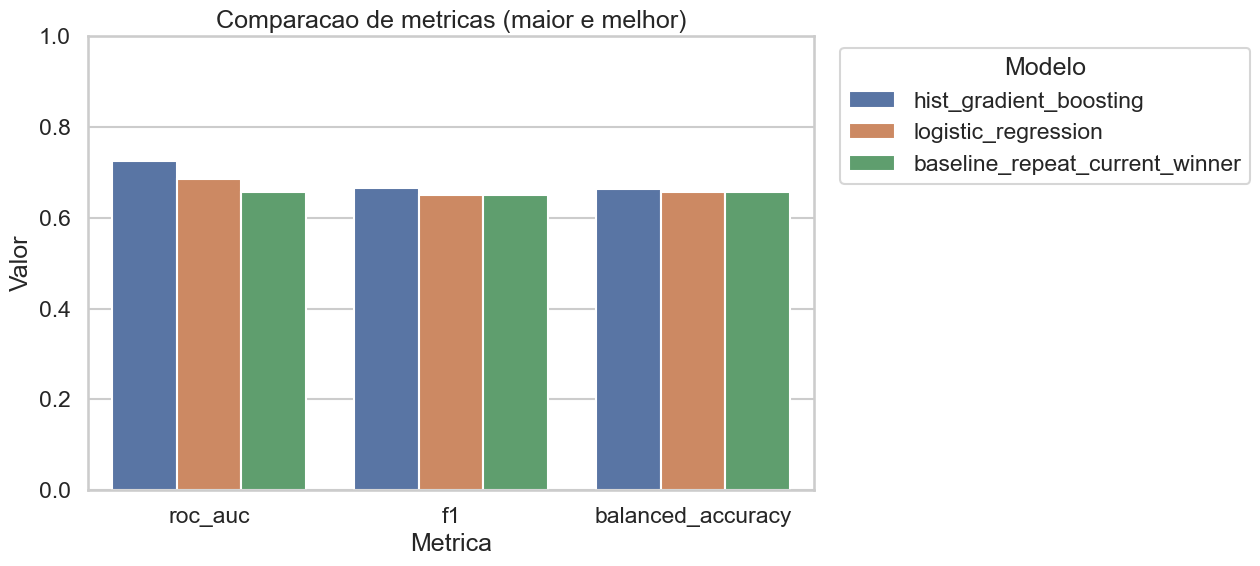

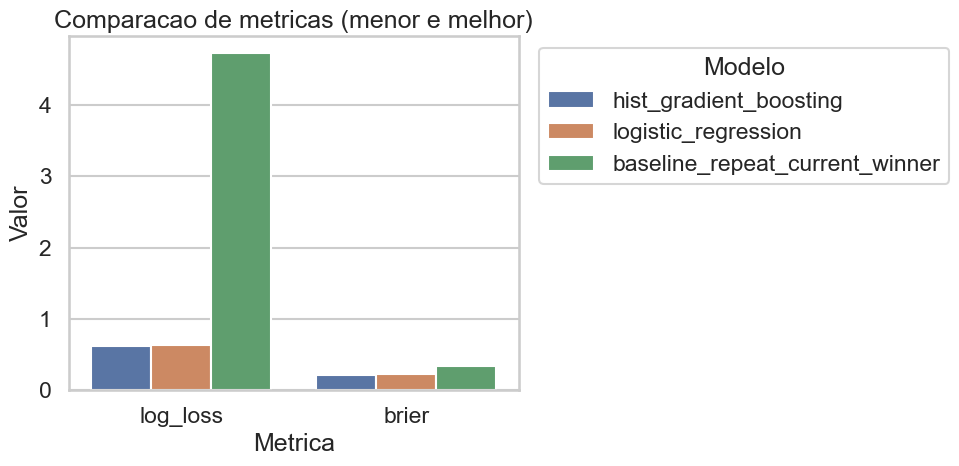

In [17]:
plot_df = training_output.metrics.copy()

# Metricas em que maior e melhor
high_is_better = ["roc_auc", "f1", "balanced_accuracy"]
plot_long = plot_df.melt(
    id_vars="model",
    value_vars=high_is_better,
    var_name="metric",
    value_name="value",
)

plt.figure(figsize=(13, 6))
sns.barplot(data=plot_long, x="metric", y="value", hue="model")
plt.ylim(0, 1)
plt.title("Comparacao de metricas (maior e melhor)")
plt.xlabel("Metrica")
plt.ylabel("Valor")
plt.legend(title="Modelo", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

# Metricas em que menor e melhor
low_is_better = ["log_loss", "brier"]
plot_low = plot_df.melt(
    id_vars="model",
    value_vars=low_is_better,
    var_name="metric",
    value_name="value",
)

plt.figure(figsize=(10, 5))
sns.barplot(data=plot_low, x="metric", y="value", hue="model")
plt.title("Comparacao de metricas (menor e melhor)")
plt.xlabel("Metrica")
plt.ylabel("Valor")
plt.legend(title="Modelo", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()


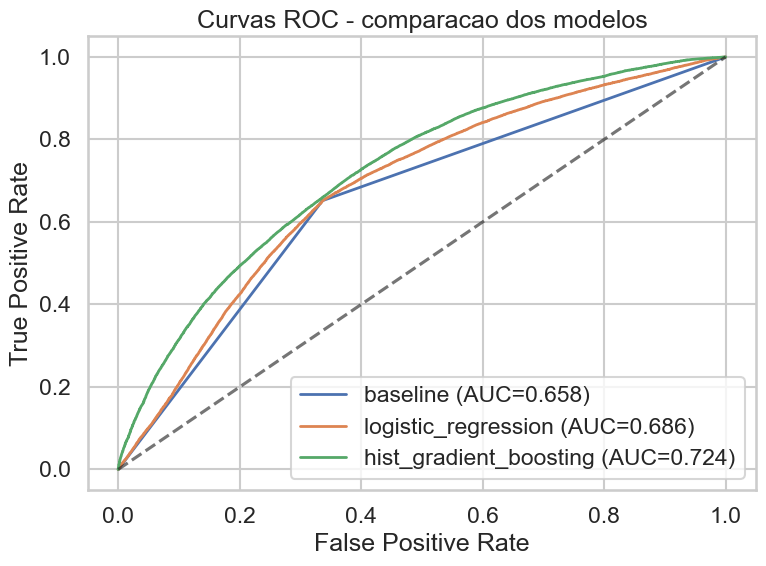

In [18]:
from sklearn.metrics import auc, roc_curve

y_true = training_output.y_test.to_numpy()

plt.figure(figsize=(8, 6))

# Baseline
fpr_b, tpr_b, _ = roc_curve(y_true, training_output.baseline_probabilities)
auc_b = auc(fpr_b, tpr_b)
plt.plot(fpr_b, tpr_b, label=f"baseline (AUC={auc_b:.3f})", linewidth=2)

# Modelos treinados
for model_name, probs in training_output.y_probabilities.items():
    fpr, tpr, _ = roc_curve(y_true, probs)
    auc_value = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f"{model_name} (AUC={auc_value:.3f})", linewidth=2)

plt.plot([0, 1], [0, 1], "k--", alpha=0.6)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Curvas ROC - comparacao dos modelos")
plt.legend()
plt.tight_layout()
plt.show()


In [19]:
best_model_name = training_output.metrics.sort_values("roc_auc", ascending=False).iloc[0]["model"]
print("Melhor modelo por ROC-AUC:", best_model_name)

print("\nSegmentacao por mapa (melhor modelo):")
print(training_output.map_segment_metrics[best_model_name].head(20))

print("\nSegmentacao por half (melhor modelo):")
print(training_output.half_segment_metrics[best_model_name].head(20))


Melhor modelo por ROC-AUC: hist_gradient_boosting

Segmentacao por mapa (melhor modelo):
       segment   rows   roc_auc        f1  balanced_accuracy  log_loss  \
0     de_cache  25780  0.722755  0.651286           0.661639  0.612703   
1    de_mirage  24289  0.726265  0.678636           0.664164  0.610381   
2   de_inferno   9832  0.722478  0.658482           0.660762  0.613739   
3  de_overpass   5116  0.715217  0.693108           0.656013  0.616900   
4     de_dust2   3717  0.724147  0.623986           0.659323  0.609475   
5     de_train   2813  0.724390  0.697018           0.660796  0.610331   
6     de_cbble    813  0.758427  0.664942           0.682165  0.587406   
7      de_nuke    239  0.701501  0.707581           0.651586  0.621637   

      brier  
0  0.212209  
1  0.211173  
2  0.212737  
3  0.214262  
4  0.210754  
5  0.211248  
6  0.200552  
7  0.216380  

Segmentacao por half (melhor modelo):
  segment   rows   roc_auc        f1  balanced_accuracy  log_loss    brier
0   

<Figure size 600x600 with 0 Axes>

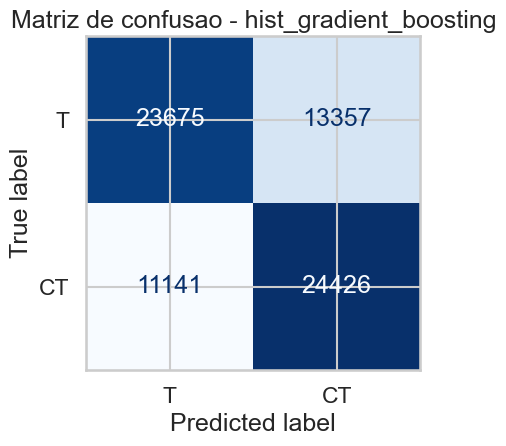

In [20]:
from sklearn.metrics import ConfusionMatrixDisplay

if best_model_name == "baseline_repeat_current_winner":
    best_probs = training_output.baseline_probabilities
else:
    best_probs = training_output.y_probabilities[best_model_name]

best_pred = (best_probs >= 0.5).astype(int)

plt.figure(figsize=(6, 6))
ConfusionMatrixDisplay.from_predictions(
    training_output.y_test,
    best_pred,
    display_labels=["T", "CT"],
    cmap="Blues",
    colorbar=False,
)
plt.title(f"Matriz de confusao - {best_model_name}")
plt.tight_layout()
plt.show()


In [21]:
# Interpretabilidade da Regressao Logistica: top coeficientes absolutos
logistic_pipeline = training_output.trained_models["logistic_regression"]
prep = logistic_pipeline.named_steps["prep"]
coef = logistic_pipeline.named_steps["model"].coef_[0]
feature_names = prep.get_feature_names_out()

coef_df = pd.DataFrame(
    {
        "feature": feature_names,
        "coef": coef,
        "abs_coef": np.abs(coef),
    }
).sort_values("abs_coef", ascending=False)

coef_df.head(20)


,feature,coef,abs_coef
33,cat__winner_side_norm_CT,0.703411,0.703411
34,cat__winner_side_norm_T,-0.672928,0.672928
29,cat__round_type_PISTOL_ROUND,0.277225,0.277225
28,cat__round_type_NORMAL,-0.206735,0.206735
15,num__winner_side_code_lag1,0.182122,0.182122
16,num__winner_side_code_lag2,-0.177711,0.177711
1,num__t_eq_val,0.149588,0.149588
25,cat__map_de_train,0.112046,0.112046
23,cat__map_de_nuke,0.101819,0.101819
26,cat__round_type_ECO,0.092198,0.092198


## 6) Tracking com MLflow

In [22]:
from rag_intelligence.round_winner import log_training_to_mlflow

LOG_TO_MLFLOW = False  # Troque para True se quiser registrar os runs
EXPERIMENT_NAME = "csgo_round_next_winner"
TRACKING_URI = os.getenv("MLFLOW_TRACKING_URI", f"file:{(root / 'mlruns').as_posix()}")

if LOG_TO_MLFLOW:
    log_training_to_mlflow(
        training_output=training_output,
        experiment_name=EXPERIMENT_NAME,
        tracking_uri=TRACKING_URI,
        target_name="winner_side_next_round",
        horizon_rounds=1,
        test_size=0.2,
        random_state=42,
    )
    print(f"Runs registrados no MLflow em: {TRACKING_URI}")
else:
    print("MLflow desativado (LOG_TO_MLFLOW=False).")


MLflow desativado (LOG_TO_MLFLOW=False).


## 7) Predicao para um exemplo

In [23]:
trained_only = training_output.metrics[training_output.metrics["model"].isin(training_output.trained_models.keys())]
chosen_model_name = trained_only.sort_values("roc_auc", ascending=False).iloc[0]["model"]
chosen_model = training_output.trained_models[chosen_model_name]

sample_df = training_output.X_test.head(1).copy()
prob_ct_next_round = float(chosen_model.predict_proba(sample_df)[0, 1])
pred_side = "CT" if prob_ct_next_round >= 0.5 else "T"

print("Modelo escolhido:", chosen_model_name)
print(f"Probabilidade prevista de CT vencer o proximo round: {prob_ct_next_round:.4f}")
print("Classe prevista:", pred_side)
sample_df


Modelo escolhido: hist_gradient_boosting
Probabilidade prevista de CT vencer o proximo round: 0.8539
Classe prevista: CT


,ct_eq_val,t_eq_val,eq_diff,round_number,overtime_flag,ct_eq_val_lag1,ct_eq_val_lag2,ct_eq_val_lag3,eq_diff_lag1,eq_diff_lag2,eq_diff_lag3,eq_diff_rollmean3,t_eq_val_lag1,t_eq_val_lag2,t_eq_val_lag3,winner_side_code_lag1,winner_side_code_lag2,winner_side_code_lag3,map,round_type,half,winner_side_norm
85,14200,7950,6250,2,0,NaN,NaN,NaN,NaN,NaN,NaN,-13025.0,NaN,NaN,NaN,NaN,NaN,NaN,de_mirage,FORCE_BUY,H1,CT
